In [2]:
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt

In [3]:
def load_and_split_data(dataset_path, split_ratio=0.8):
    """
    Loads file paths from the dataset and splits them into training and testing sets.
    """
    filepaths = {}
    for speaker_id in os.listdir(dataset_path):
        filepaths[speaker_id] = []
        speaker_path = os.path.join(dataset_path, speaker_id)
        if not os.path.isdir(speaker_path):
            continue
        for video_folder in os.listdir(speaker_path):
            video_path = os.path.join(speaker_path, video_folder)
            if not os.path.isdir(video_path):
                continue
            for file in os.listdir(video_path):
                if file.endswith('.wav'):
                    filepaths[speaker_id].append(os.path.join(video_path, file))

    train_files = {}
    test_files = {}
    for speaker, files in filepaths.items():
        if not files:
            continue
        np.random.shuffle(files)
        split_idx = int(len(files) * split_ratio)
        train_files[speaker] = files[:split_idx]
        test_files[speaker] = files[split_idx:]

    return train_files, test_files, list(filepaths.keys())

In [4]:
def extract_features(file_list, n_mfcc):
    """
    Extracts MFCC features from a list of audio files.
    """
    features = []
    for file in file_list:
        try:
            y, sr = librosa.load(file, sr=None)
            if len(y) == 0:
                continue
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
            features.extend(mfcc.T)
        except Exception as e:
            print(f"Error processing {file}: {e}")
    return np.array(features)

def prepare_features(train_files, test_files, speakers, n_mfcc):
    """
    Extracts and saves features for training and testing sets.
    """
    train_features = {}
    test_features = {}

    for speaker in speakers:
        if speaker in train_files:
            train_features[speaker] = extract_features(train_files[speaker], n_mfcc)
        if speaker in test_files:
            test_features[speaker] = {file: extract_features([file], n_mfcc) for file in test_files[speaker]}

    return train_features, test_features

In [5]:
# Gaussian Mixture Model Implementation
# Implements a simple GMM using the Expectation-Maximization algorithm

class GaussianMixtureModel:
    def __init__(self, n_components=2, n_iters=200, reg_covar=1e-6):
        self.n_components = n_components
        self.n_iters = n_iters
        self.reg_covar = reg_covar
        self.means = None
        self.covariances = None
        self.weights = None

    def fit(self, X):
        n_samples, n_features = X.shape
        if n_samples < self.n_components:
            # Not enough data to initialize components
            # Handle this case, e.g., by reducing n_components or skipping
            print(f"Warning: n_samples={n_samples} < n_components={self.n_components}. Skipping fit.")
            self.means = np.zeros((self.n_components, n_features))
            self.covariances = np.array([np.eye(n_features)] * self.n_components)
            self.weights = np.ones(self.n_components) / self.n_components
            return

        # Initialize parameters
        self.means = X[np.random.choice(n_samples, self.n_components, False)]
        self.covariances = np.array([np.eye(n_features)] * self.n_components)
        self.weights = np.ones(self.n_components) / self.n_components

        for _ in range(self.n_iters):
            # E-step
            responsibilities = self._e_step(X)
            # M-step
            self._m_step(X, responsibilities)

    def score(self, X):
        # Calculate the log-likelihood of each sample
        log_likelihood = np.zeros(X.shape[0])
        for k in range(self.n_components):
            log_likelihood += self.weights[k] * self._gaussian(X, self.means[k], self.covariances[k])

        # To avoid log(0)
        log_likelihood[log_likelihood == 0] = np.finfo(float).eps

        # Return the mean log-likelihood
        return np.log(log_likelihood).mean()

    def _e_step(self, X):
        n_samples = X.shape[0]
        responsibilities = np.zeros((n_samples, self.n_components))

        for k in range(self.n_components):
            responsibilities[:, k] = self.weights[k] * self._gaussian(X, self.means[k], self.covariances[k])

        # To avoid division by zero
        row_sum = responsibilities.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1.0
        responsibilities /= row_sum
        return responsibilities

    def _m_step(self, X, responsibilities):
        n_samples, n_features = X.shape
        Nk = responsibilities.sum(axis=0)

        for k in range(self.n_components):
            # Add a small epsilon to avoid division by zero
            Nk_k = Nk[k] + 1e-6
            self.means[k] = (responsibilities[:, k][:, np.newaxis] * X).sum(axis=0) / Nk_k
            diff = X - self.means[k]
            # Add regularization to the covariance matrix
            self.covariances[k] = (responsibilities[:, k][:, np.newaxis] * diff).T @ diff / Nk_k + np.eye(n_features) * self.reg_covar
            self.weights[k] = Nk[k] / n_samples

    def _gaussian(self, X, mean, covariance):
        n_features = X.shape[1]
        diff = X - mean

        try:
            inv_cov = np.linalg.inv(covariance)
            det_cov = np.linalg.det(covariance)
        except np.linalg.LinAlgError:
            # If covariance is singular, use pseudo-inverse or return small probability
            covariance += np.eye(n_features) * self.reg_covar
            try:
                inv_cov = np.linalg.inv(covariance)
                det_cov = np.linalg.det(covariance)
            except np.linalg.LinAlgError:
                return np.full(X.shape[0], 1e-18)


        # To avoid log of zero or negative determinant
        if det_cov <= 0:
            return np.full(X.shape[0], 1e-18)

        exponent = np.exp(-0.5 * np.sum(diff @ inv_cov * diff, axis=1))
        denominator = np.sqrt((2 * np.pi) ** n_features * det_cov)
        return exponent / (denominator + 1e-6) # Add epsilon to avoid division by zero

In [6]:
def train_models(train_features, speakers, n_components, n_iters=200):
    """
    Trains GMMs for each speaker.
    """
    gmm_models = {}
    for speaker in speakers:
        if speaker not in train_features or train_features[speaker].shape[0] == 0:
            continue
        gmm = GaussianMixtureModel(n_components=n_components, n_iters=n_iters)
        gmm.fit(train_features[speaker])
        gmm_models[speaker] = gmm
    return gmm_models

In [7]:
def evaluate_models(test_features, gmm_models, speakers):
    """
    Evaluates the trained GMM models on the test set.
    """
    correct = 0
    total_tests = 0
    for speaker, files in test_features.items():
        if speaker not in speakers:
            continue
        for file, features in files.items():
            if features.shape[0] == 0:
                continue
            total_tests += 1
            scores = {}
            for speaker_id, gmm in gmm_models.items():
                if speaker_id not in speakers:
                    continue
                score = gmm.score(features)
                scores[speaker_id] = score

            if not scores:
                continue

            predicted_speaker = max(scores, key=scores.get)
            if predicted_speaker == speaker:
                correct += 1

    if total_tests > 0:
        accuracy = correct / total_tests
        return accuracy
    else:
        return 0.0

In [8]:
def run_experiment(n_mfcc, n_components):
    """
    Runs a full experiment for a given n_mfcc and n_components.
    """
    print(f"Running experiment with n_mfcc={n_mfcc}, n_components={n_components}")

    # 1. Load and split data
    dataset_path = 'dataset/vox1_indian/content/vox_indian/'
    train_files, test_files, speakers = load_and_split_data(dataset_path)

    # 2. Prepare features
    train_features, test_features = prepare_features(train_files, test_files, speakers, n_mfcc)

    # 3. Train models
    gmm_models = train_models(train_features, speakers, n_components)

    # 4. Evaluate models
    accuracy = evaluate_models(test_features, gmm_models, speakers)

    print(f'Accuracy for n_mfcc={n_mfcc}, n_components={n_components}: {accuracy * 100:.2f}%')
    return accuracy

def plot_results(param_values, accuracies, param_name):
    """
    Plots the accuracy vs. the hyperparameter values.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(param_values, accuracies, marker='o')
    plt.title(f'Accuracy vs. {param_name}')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

Running experiment with n_mfcc=2, n_components=16
Accuracy for n_mfcc=2, n_components=16: 24.06%
Running experiment with n_mfcc=6, n_components=16
Accuracy for n_mfcc=6, n_components=16: 67.79%
Running experiment with n_mfcc=12, n_components=16
Accuracy for n_mfcc=12, n_components=16: 88.89%
Running experiment with n_mfcc=18, n_components=16
Accuracy for n_mfcc=18, n_components=16: 86.85%
Running experiment with n_mfcc=24, n_components=16
Accuracy for n_mfcc=24, n_components=16: 1.12%


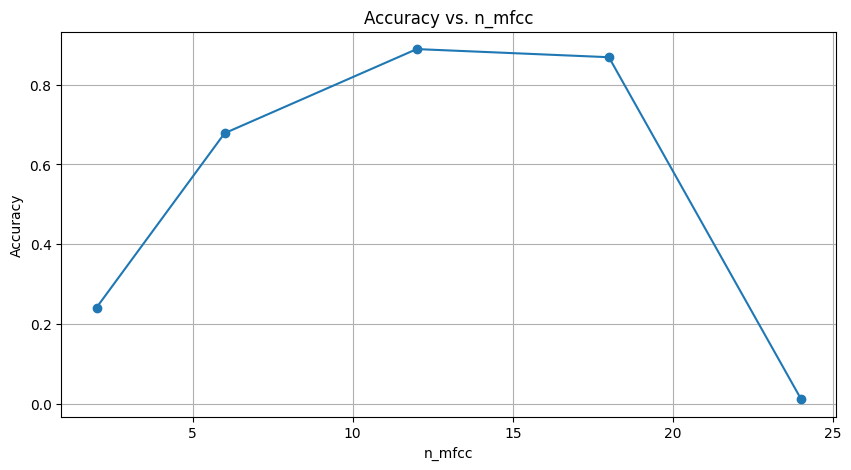

Running experiment with n_mfcc=8, n_components=2
Accuracy for n_mfcc=8, n_components=2: 54.43%
Running experiment with n_mfcc=8, n_components=6
Accuracy for n_mfcc=8, n_components=6: 72.88%
Running experiment with n_mfcc=8, n_components=12
Accuracy for n_mfcc=8, n_components=12: 77.17%
Running experiment with n_mfcc=8, n_components=18
Accuracy for n_mfcc=8, n_components=18: 82.47%
Running experiment with n_mfcc=8, n_components=24
Accuracy for n_mfcc=8, n_components=24: 78.08%


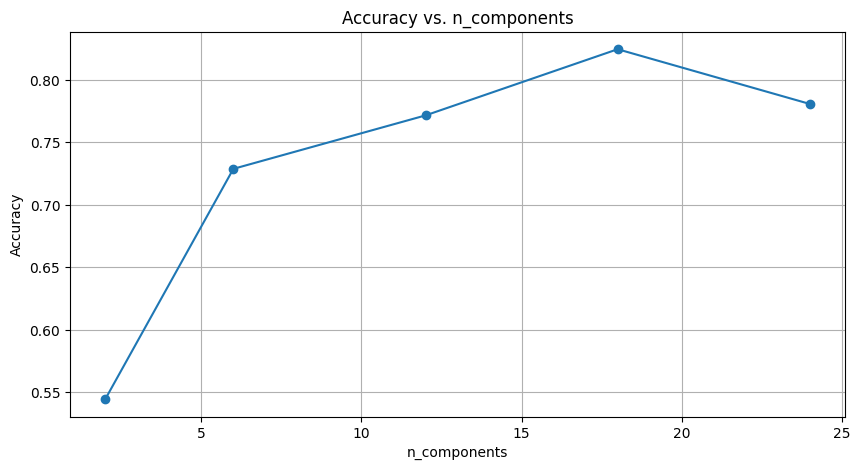

In [8]:
# Main execution block

# Hyperparameter analysis for n_mfcc
n_mfcc_values = [2, 6, 12, 18, 24]
n_components_fixed = 16
mfcc_accuracies = []

for n_mfcc in n_mfcc_values:
    accuracy = run_experiment(n_mfcc=n_mfcc, n_components=n_components_fixed)
    mfcc_accuracies.append(accuracy)

plot_results(n_mfcc_values, mfcc_accuracies, 'n_mfcc')

# Hyperparameter analysis for n_components
n_mfcc_fixed = 8
n_components_values = [2, 6, 12, 18, 24]
components_accuracies = []

for n_components in n_components_values:
    accuracy = run_experiment(n_mfcc=n_mfcc_fixed, n_components=n_components)
    components_accuracies.append(accuracy)

plot_results(n_components_values, components_accuracies, 'n_components')

In [10]:
# Final experiment with best hyperparameters
best_n_mfcc = 12  # Example best value from analysis
best_n_components = 16  # Example best value from analysis
final_accuracy = run_experiment(n_mfcc=best_n_mfcc, n_components=best_n_components)
print(f'Final accuracy with n_mfcc={best_n_mfcc} and n_components={best_n_components}: {final_accuracy * 100:.2f}%')

Running experiment with n_mfcc=12, n_components=16
Accuracy for n_mfcc=12, n_components=16: 88.48%
Final accuracy with n_mfcc=12 and n_components=16: 88.48%
